# Завдання на використання SQL в Python

1.Встановіть бібліотеку `mysql-connector-python` через pip aбо через conda.

In [51]:
!pip install mysql-connector-python

In [52]:
import mysql.connector
from mysql.connector.connection import MySQLConnection
import datetime

2.В змінній `con` створіть підключення до бази даних employees за аналогією того, як це робилось в лекції:

In [53]:
con = mysql.connector.connect(user='user1', password='7oygWy6P',
                              host='3.68.62.36',
                              database='employees')

3.Виберіть максимальну і мінімальну дати найму співробітників використовуючи `con.cursor()`. Аби отримати результати в кінці, виконайте `cursor.fetchall()`.

In [54]:
cursor = con.cursor()

In [55]:
cursor.execute("SELECT MAX(hire_date), MIN(hire_date) FROM employees")

In [56]:
result = cursor.fetchall()

In [57]:
result

[(datetime.date(2000, 1, 28), datetime.date(1985, 1, 1))]

Очікуваний результат:  
    `[(datetime.date(2000, 1, 28), datetime.date(1985, 1, 1))]`

4.Давайте зберемо інформацію про останню ЗП кожного співробіткника в базі. З використанням `con.cursor()` виберіть з таблиці `salaries` для кожного співробітника його номер, останню в базі даних (тобто ту, що відповідає найновішій `to_date`) ЗП, та значення `from_date`, `to_date` для цієї ЗП.

Результати запишіть у pandas DataFrame, який збережіть у змінну `res`. Як взяти з курсора назви колонок - вже наведено. На екран виведіть назви колонок в змінній `res`, розмір цього датафрейму та перші 3 записи в ньому.

УВАГА! Зверніть увагу, що ЗП може оновлюватись протягом одного дня, тобто є випадки, коли апдейт ЗП був в певний день, скажімо 2001-01-01 і потім стався ще один апдейт ЗП цьому співробітнику цього самого дня. Запит має це враховувати.
Також, теоретично ЗП може бути зменшена. Тож, брати дату з максимальною ЗП буде неправильно з точки зору бізнес логіки. Треба саме останнє історичне значення ЗП кожного співробітника.

In [58]:
import pandas as pd

In [59]:
query = """
    SELECT s.emp_no, s.salary, s.from_date, s.to_date
    FROM salaries s
    JOIN (
        SELECT emp_no, MAX(from_date) as max_from_date, MAX(to_date) as max_to_date
        FROM salaries
        GROUP BY emp_no
    ) max_dates
    ON s.emp_no = max_dates.emp_no AND s.from_date = max_dates.max_from_date AND s.to_date = max_dates.max_to_date
"""

cursor.execute(query)

columns = [i[0] for i in cursor.description]
data = cursor.fetchall()
res = pd.DataFrame(data, columns=columns)


In [60]:
res.columns

Index(['emp_no', 'salary', 'from_date', 'to_date'], dtype='object')

In [61]:
res.shape

(300024, 4)

In [62]:
res.head(3)

,emp_no,salary,from_date,to_date
0,10001,88958,2002-06-22,9999-01-01
1,10002,72527,2001-08-02,9999-01-01
2,10003,43311,2001-12-01,9999-01-01


Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1lNvzbAebtkj3C2v-I5AE6HkMH8MTI1kA)

5.В утвореній вибірці в змінній `res` скільки значень `to_date` рівні `9999-01-01`, а скільки - ні? Увага! Для виконання цього завдання важливо розуміти, який тип даних у значень колонки `to_date`. Зʼясуйте це, і потім напишіть фільтр для виводу потрібного результату.

In [63]:
to_date_dtype = res['to_date'].dtype

In [64]:
print(to_date_dtype)

object


In [65]:
to_date_9999_count = len(res[res['to_date'].astype(str) == '9999-01-01'])
to_date_not_9999_count = len(res[res['to_date'].astype(str) != '9999-01-01'])

print("Кількість значень to_date, рівних '9999-01-01':", to_date_9999_count)
print("Кількість значень to_date, не рівних '9999-01-01':", to_date_not_9999_count)


Кількість значень to_date, рівних '9999-01-01': 240124
Кількість значень to_date, не рівних '9999-01-01': 59900


6.Виведіть візуально розподіл (гістограму) зарплат співробітників, які досі працюють в компанії, використовуючи результат попереднього завдання. Співробітниками, які досі працюють в компанії вважаємо тих, в кого to_date має значення 9999-01-01. Обовʼязково підпишіть графік і вісі.

Ці три завдання - приклад, як нам може бути зручно витягнути дані з бази певним запитом, а потім використати витягнуту вибірку у Python для подальшого аналізу.

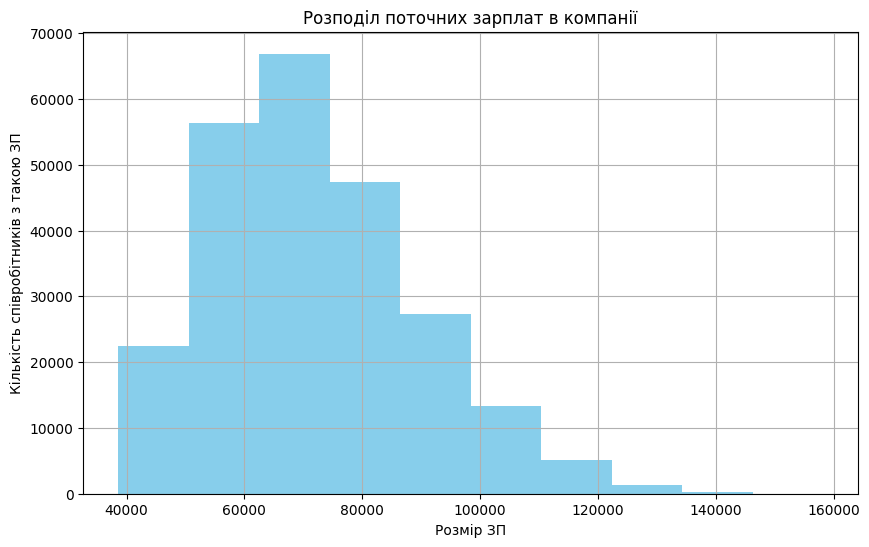

In [66]:
import matplotlib.pyplot as plt

still_working = res[res['to_date'].astype(str) == '9999-01-01']

plt.figure(figsize=(10, 6))
plt.hist(still_working['salary'], bins=10, color='skyblue')
plt.title('Розподіл поточних зарплат в компанії')
plt.xlabel('Розмір ЗП')
plt.ylabel('Кількість співробітників з такою ЗП')
plt.grid(True)
plt.show()


Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1j8MHLC1E0revbQLM9B0UJs6tVEgoWhmK)

НЕ ЗАБУВАЄМО ЗАКРИТИ ПІДКЛЮЧЕННЯ ДО БАЗИ :)

In [67]:
con.close()